**Author:** Biswajit Jana  
**Date:** January 7, 2026  

# SDSS class-composition audit for one sky patch

**Scientific question:** What do the preserved aggregate counts support when the original 800 source rows were not saved?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
counts=pd.DataFrame({'class':['GALAXY','STAR','QSO'],'count':[400,268,132]}); sample=counts.loc[counts.index.repeat(counts['count'])].reset_index(drop=True); counts['fraction']=counts['count']/counts['count'].sum(); print(counts.to_string(index=False))

 class  count  fraction
GALAXY    400     0.500
  STAR    268     0.335
   QSO    132     0.165


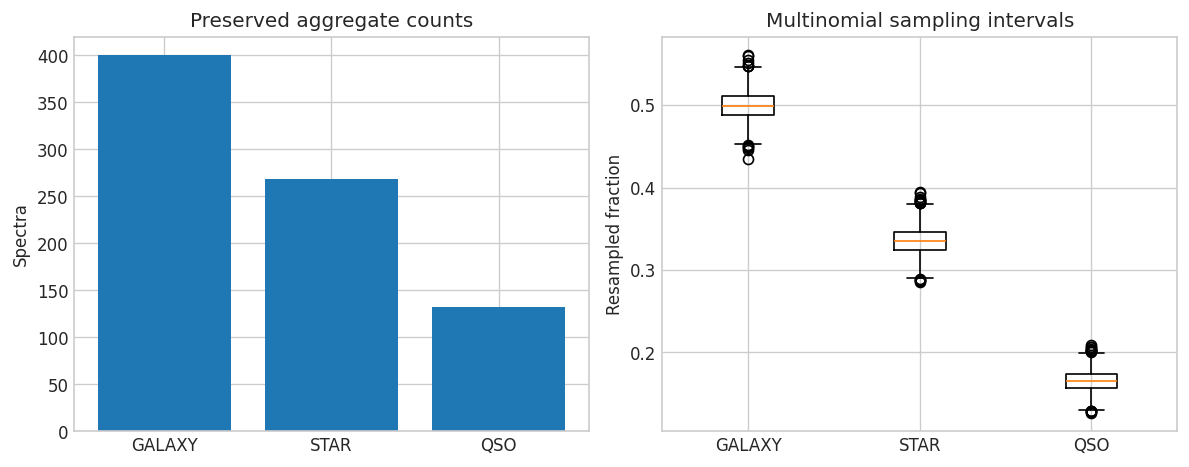

In [3]:
draws=RNG.multinomial(800,counts.fraction,2000)/800; lo,hi=np.percentile(draws,[2.5,97.5],axis=0); counts['p025']=lo; counts['p975']=hi; counts.to_csv('sdss_patch_class_fractions.csv',index=False); fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].bar(counts['class'],counts['count']); ax[0].set(ylabel='Spectra',title='Preserved aggregate counts'); ax[1].boxplot([draws[:,i] for i in range(3)],tick_labels=counts['class']); ax[1].set(ylabel='Resampled fraction',title='Multinomial sampling intervals'); fig.tight_layout(); fig.savefig('sdss_class_fraction_audit.png',dpi=180); plt.show()

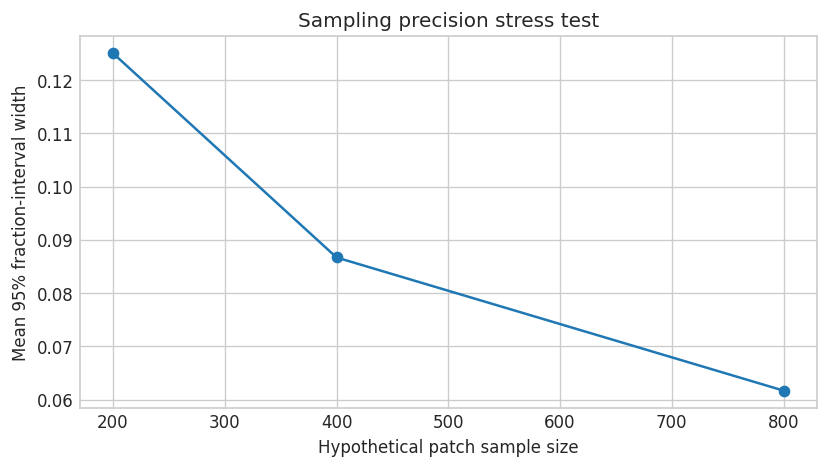

In [4]:
sizes=[200,400,800]; width=[]
for n in sizes:
 d=RNG.multinomial(n,counts.fraction,2000)/n; width.append(np.mean(np.percentile(d,97.5,axis=0)-np.percentile(d,2.5,axis=0)))
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(sizes,width,'o-'); ax.set(xlabel='Hypothetical patch sample size',ylabel='Mean 95% fraction-interval width',title='Sampling precision stress test'); fig.tight_layout(); fig.savefig('sdss_class_precision_stress.png',dpi=180); plt.show()

In [5]:
sample_size=800; results=[f'GALAXY {counts.iloc[0].fraction:.1%}, STAR {counts.iloc[1].fraction:.1%}, QSO {counts.iloc[2].fraction:.1%}',f'QSO 95% multinomial interval {counts.iloc[2].p025:.1%}–{counts.iloc[2].p975:.1%}','aggregate counts reproduce the old output but cannot recover subclass or redshift distributions']; validation='Class fractions use multinomial resampling and interval width is tested at three sample sizes.'; quality_checks=[{'name':'Counts sum to 800','status':'pass'},{'name':'Sampling intervals','status':'pass'},{'name':'Source-level table','status':'not available'}]; tags=['SDSS','spectral classes','aggregate audit','selection']

In [6]:
result={'id':'2026-07-30-spectral-type-distribution','title':'SDSS class-composition audit for one sky patch','archive':'SDSS legacy aggregate','date':'2026-07-30','question':'What do the preserved aggregate counts support when the original 800 source rows were not saved?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'sdss/2026-07-30-spectral-type-distribution/notebook.ipynb','hero':'sdss/2026-07-30-spectral-type-distribution/sdss_class_fraction_audit.png','figures':['sdss/2026-07-30-spectral-type-distribution/sdss_class_fraction_audit.png', 'sdss/2026-07-30-spectral-type-distribution/sdss_class_precision_stress.png'],'research_level':'Reproduction','claim_type':'Multinomial class-fraction audit','provenance':['Original SDSS SQL query printed in notebook', 'executed aggregate counts: 400 galaxies, 268 stars, 132 QSOs'],'artifacts':['sdss/2026-07-30-spectral-type-distribution/sdss_patch_class_fractions.csv'],'quality_checks':quality_checks,'limitations':['source-level rows were not saved', 'TOP 800 without explicit ordering is not a random sky sample', 'pipeline classes and subclasses are not audited individually'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

GALAXY 50.0%, STAR 33.5%, QSO 16.5%
QSO 95% multinomial interval 13.9%–19.0%
aggregate counts reproduce the old output but cannot recover subclass or redshift distributions


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

              name        status
 Counts sum to 800          pass
Sampling intervals          pass
Source-level table not available


## Interpretation and references

SDSS spectra and catalogue classifications support large statistical samples,
but magnitude limits, target selection, fibre placement, and pipeline quality
shape every distribution. Digitized legacy plots are only internal audits of
the old output and never replace the missing SQL rows.

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- SDSS-IV overview: https://doi.org/10.3847/1538-3881/aafc2b
- DR16 optical spectra: https://www.sdss4.org/dr16/spectro/